Figure S9: Distribution of single-gene log2aFC effects. A The second largest PIP-weighted | log2aFC | for each QTL on any eGene in a cluster vs the largest PIP-weighted | log2aFC |  on any eGene in a cluster, split by if the QTL is discovered as both a pcQTL and eQTL, an eQTL only, or a pcQTL only. B The distance from the lead variant of the QTL credible set to the TSS of the second largest  | log2aFC |  gene vs the largest  | log2aFC |  gene. C Annotation enrichments for PIP-weighted variant effect predictor categories for QTL credible sets split by if the CV of PIP-weighted  | log2aFC |  is higher or lower than 0.8.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import upsetplot as up
from scipy.stats import spearmanr, ttest_ind, ttest_rel, norm
from matplotlib.colors import LinearSegmentedColormap, LogNorm
import ast
import pyranges as pr
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from scipy import stats



from tqdm.auto import tqdm 
tqdm.pandas()

prefix = '/home/klawren/oak/pcqtls'
import yaml
config_path= f'{prefix}/config_old/main_pcqtl.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

import sys
sys.path.append('/home/klawren/oak/pcqtls/workflow/scripts')
from utils import *
from annotate_clusters import * 
import call_clusters



%config InlineBackend.figure_formats = ['png']
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
plt.rcParams.update({'font.size': 7})

/home/klawren/.pixi/envs/python/lib/python3.12/site-packages/sorted_nearest/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
qtl_signal_groups = load_across_tissues(config, load_qtl_signal_groups)
qtl_signal_groups['qtl_group_label'] = np.where((qtl_signal_groups['num_e_coloc'] > 0), np.where((qtl_signal_groups['num_pc_coloc'] > 0), 'Both', 'eQTL only'), 'pcQTL only')

eqtl_susie = load_across_tissues(config, load_e_susie_r)
pcqtl_susie = load_across_tissues(config, load_pc_susie_r)

pcqtl_afc = load_across_tissues(config, load_pc_afc)
eqqtl_afc = load_across_tissues(config, load_e_afc)
qtl_afc = pd.concat([pcqtl_afc, eqqtl_afc]).drop_duplicates(['tissue_id', 'pid', 'sid']).reset_index(drop=True)

pcqtl_susie['cluster_id'] = pcqtl_susie['phenotype_id'].str.split('_pc').str[0]
pcqtl_susie['gene_id'] = pcqtl_susie['cluster_id'].str.split('_')

eqtl_susie['cluster_id'] = eqtl_susie['phenotype_id'].str.split('_e').str[0]
eqtl_susie['gene_id'] = eqtl_susie['cluster_id'].str.split('_')

susie = pd.concat([pcqtl_susie, eqtl_susie], keys=['pcQTL', 'eQTL'], names=['qtl_type']).reset_index()

In [3]:
# Load GENCODE annotations
gid_gencode = pd.read_table(f"{config['working_dir']}/{config["gencode_path"]}").set_index('gene_id')
gid_gencode['tss_pos'] = gid_gencode['tss_pos'].apply(literal_eval)

# add lead variant information, max pip per phenotype-tissue-cs id group
lead_variant_idx = susie.groupby(['phenotype_id', 'tissue_id', 'cs_id'])['pip'].idxmax()
lead_variant_map = susie.loc[lead_variant_idx, ['phenotype_id', 'tissue_id', 'cs_id', 'variant_id']].set_index(['phenotype_id', 'tissue_id', 'cs_id'])['variant_id']
susie['lead_variant_id'] = susie.set_index(['phenotype_id', 'tissue_id', 'cs_id']).index.map(lead_variant_map)
susie['lead_variant_position'] = susie['lead_variant_id'].str.split('_').str[1].astype(int)
susie_explode = susie.explode('gene_id')

tss_merged_susie = pd.merge(susie_explode, gid_gencode.explode('tss_pos'), left_on='gene_id', right_on='gene_id', how='left')
tss_merged_susie['lead_var_tss_dist'] = np.where(tss_merged_susie['strand'] == '+', 
                tss_merged_susie['lead_variant_position'] - tss_merged_susie['tss_pos'], 
                tss_merged_susie['tss_pos'] - tss_merged_susie['lead_variant_position'])

lead_var_tss_dist = tss_merged_susie.groupby(['phenotype_id', 'cs_id', 'tissue_id', 'gene_id']).agg(
    lead_var_tss_dist=('lead_var_tss_dist', 'min')).reset_index()

In [4]:
# merge in afc information
susie_explode_afc = pd.merge(susie_explode, qtl_afc[['pid', 'sid', 'tissue_id', 'log2_aFC']], left_on=['gene_id', 'variant_id', 'tissue_id'], 
    right_on=['pid', 'sid', 'tissue_id'], how='left')

# pip-weighted afc over credible set
susie_explode_afc['pip_afc'] = susie_explode_afc['pip'] * susie_explode_afc['log2_aFC']
credible_set_grouped_afc = susie_explode_afc.groupby(['phenotype_id', 'cs_id', 'tissue_id', 'gene_id', 'qtl_type']).agg({'pip_afc':'sum', 'pip':'sum'}).reset_index()
credible_set_grouped_afc['pip_afc_weighted'] = credible_set_grouped_afc['pip_afc']/credible_set_grouped_afc['pip']
credible_set_grouped_afc['abs_pip_afc_weighted'] = credible_set_grouped_afc['pip_afc_weighted'].abs()

# add in lead var distances
credible_set_grouped_afc = pd.merge(credible_set_grouped_afc, lead_var_tss_dist, on=['phenotype_id', 'cs_id', 'tissue_id', 'gene_id'], how='left')
credible_set_grouped_afc['lead_var_tss_dist'] = credible_set_grouped_afc['lead_var_tss_dist'].abs()

In [5]:
# For each group of tissue-phenotype-cs, get the rows with the largest and second largest absolute pip-weighted afc,
# and extract both the values and the corresponding distances

def get_top2_afc_and_dist(df):
    # Sort by absolute pip-weighted afc descending
    sorted_df = df.sort_values('abs_pip_afc_weighted', ascending=False)
    # Get largest and second largest rows
    top1 = sorted_df.iloc[0]
    top2 = sorted_df.iloc[1] if len(sorted_df) > 1 else top1
    return pd.Series({
        'max_abs_pip_afc_weighted': top1['abs_pip_afc_weighted'],
        'second_abs_pip_afc_weighted': top2['abs_pip_afc_weighted'],
        'distance_first': top1['lead_var_tss_dist'],
        'distance_second': top2['lead_var_tss_dist']
    })

afc_dist_summary = credible_set_grouped_afc.groupby(['tissue_id', 'phenotype_id', 'cs_id']).progress_apply(get_top2_afc_and_dist).reset_index()

  0%|          | 0/37315 [00:00<?, ?it/s]

/home/klawren/.pixi/envs/python/lib/python3.12/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


In [133]:
# add in labels about pcqtl vs eqtl vs both
qtl_signal_groups['cs_phenotype_id'] = qtl_signal_groups['signal_id'].str.split('-')
afc_dist_summary['cs_phenotype_id'] = afc_dist_summary['phenotype_id'] + '_cs_' + afc_dist_summary['cs_id'].astype(str)
cluster_grouped_afc = pd.merge(afc_dist_summary, qtl_signal_groups.explode('cs_phenotype_id'), on=['tissue_id', 'cs_phenotype_id'], how='left')

In [9]:
sum((afc_dist_summary['distance_first'] < afc_dist_summary['distance_second']))/len(afc_dist_summary) * 100

63.794720621733894

In [10]:
# load in vep annotations
susie_annotated = load_across_tissues(config, load_susie_annotated)

# format the egene info to be a list instead of a string
susie_annotated = susie_annotated[~(susie_annotated['egene_id_list'] == '[nan]')]
susie_annotated['egene_qtl_slope'] = susie_annotated['egene_qtl_slope'].apply(ast.literal_eval)
susie_annotated['egene_id_list'] = susie_annotated['egene_id_list'].apply(ast.literal_eval)

# explode to egenes
susie_annotated_explode = susie_annotated.explode(['egene_qtl_slope', 'egene_id_list'])
susie_annotated_explode['egene_id'] = susie_annotated_explode['egene_id_list']

In [11]:
# add annotation information 
def get_gene_matched_effect(row):
    gene_matched_effect = []
    for vep_effect in row['vep_info'].split(','):
        if row['egene_id'].split('.')[0] in vep_effect:
            gene_matched_effect.append(vep_effect.split('|')[1])
    return list(set(gene_matched_effect))

susie_annotated_explode['vep_info_gene'] = susie_annotated_explode.progress_apply(get_gene_matched_effect, axis=1).astype(str)
# promoter, enahncer, and ctcf are not gene specific
susie_annotated_explode['vep_CTCF'] = susie_annotated_explode['vep_info'].str.contains('CTCF_binding_site').astype(float) * susie_annotated_explode['pip']
susie_annotated_explode['vep_enhancer'] = susie_annotated_explode['vep_info'].str.contains('enhancer').astype(float) * susie_annotated_explode['pip']
susie_annotated_explode['vep_promoter'] = susie_annotated_explode['vep_info'].str.contains('promoter').astype(float) * susie_annotated_explode['pip']
susie_annotated_explode['qtl_in_tad'] = (susie_annotated_explode['qtl_in_tad']) * susie_annotated_explode['pip']
susie_annotated_explode['vep_gene_matched_splice'] = susie_annotated_explode['vep_info_gene'].str.contains('splice', regex=True).astype(float) * susie_annotated_explode['pip']
susie_annotated_explode['vep_gene_matched_nmd'] = susie_annotated_explode['vep_info_gene'].str.contains('stop_gained', regex=True).astype(float) * susie_annotated_explode['pip']
susie_annotated_explode['vep_any_effect'] = (susie_annotated_explode['vep_info_gene'].str.strip("'[],").apply(len) > 0).astype(float) * susie_annotated_explode['pip']
susie_annotated_explode['egene_qtl_slope'] = susie_annotated_explode['egene_qtl_slope'] * susie_annotated_explode['pip']

  0%|          | 0/2482482 [00:00<?, ?it/s]

In [12]:
# group into credible sets, summing over pip weighted effects
cs_grouped = susie_annotated_explode.groupby(['phenotype_id', 'cs_id', 'tissue_id', 'cluster_id' ,'egene_id']).agg(vep_any_effect=('vep_any_effect','sum'),
                                                                                                                  ctcf=('vep_CTCF','sum'),
                                                                                                                  enhancer=('vep_enhancer','sum'),
                                                                                                                  promoter=('vep_promoter','sum'),
                                                                                                                  tad=('qtl_in_tad','sum'),
                                                                                                                  splice=('vep_gene_matched_splice','sum'),
                                                                                                                  nmd=('vep_gene_matched_nmd','sum'),
                                                                                                                  pip_sum=('pip','sum'),
                                                                                                                  type=('type','first'),
                                                                                                                  lead_variant_id=('lead_variant_id','first')
                                                                                                                  )

annotation_columns = cs_grouped.columns[:-3]
for c in annotation_columns:
    cs_grouped[c] = cs_grouped[c] / cs_grouped['pip_sum']
cs_grouped = cs_grouped.reset_index().reset_index()

# add in underlying signal info
cs_grouped['cs_phenotype_id'] = cs_grouped['phenotype_id'] + '_cs_' + cs_grouped['cs_id'].str.split('_cs_').str[-1]
cs_grouped_annotation = pd.merge(cs_grouped, qtl_signal_groups.explode('cs_phenotype_id'), on=['tissue_id', 'cs_phenotype_id'], how='left')

In [ ]:
# group over egenes in a cluster                                                      
egene_grouped_annotation = cs_grouped_annotation.groupby(['tissue_id', 'cs_phenotype_id', 'signal_id']).agg(vep_single_gene=('vep_any_effect',lambda values: (sorted(values, reverse=True)[0]>0) & (sorted(values, reverse=True)[1]==0)), 
                                                             vep_multi_gene=('vep_any_effect',lambda values: sorted(values, reverse=True)[1]>0), 
                                                             ctcf=('ctcf',lambda values: max(values)), 
                                                             enhancer=('enhancer',lambda values: max(values)), 
                                                             vep_promoter=('promoter',lambda values: max(values)), 
                                                             tad=('tad',lambda values: max(values)), 
                                                             splice=('splice',lambda values: max(values)), 
                                                             nmd=('nmd',lambda values: max(values)),
                                                             qtl_group_label=('qtl_group_label', 'first'), 
                                                             cluster_id=('cluster_id_x','first'))

# group over genes in a cluster that a credible set impacts
cluster_grouped_afc_cv = credible_set_grouped_afc.groupby(['tissue_id', 'phenotype_id', 'cs_id', 'qtl_type']).agg(
    mean_afc=('abs_pip_afc_weighted', 'mean'), 
    std_afc=('abs_pip_afc_weighted', 'std'), 
    max_afc=('abs_pip_afc_weighted', 'max')).reset_index()

cluster_grouped_afc_cv['cv_afc'] =  cluster_grouped_afc_cv['std_afc'] / cluster_grouped_afc_cv['mean_afc'] * 100

# add in labels about pcqtl vs eqtl vs both
qtl_signal_groups['cs_phenotype_id'] = qtl_signal_groups['signal_id'].str.split('-')
cluster_grouped_afc_cv['cs_phenotype_id'] = cluster_grouped_afc_cv['phenotype_id'] + '_cs_' + cluster_grouped_afc_cv['cs_id'].astype(str)
cluster_grouped_afc_cv = pd.merge(cluster_grouped_afc_cv, qtl_signal_groups.explode('cs_phenotype_id'), on=['tissue_id', 'cs_phenotype_id'], how='left')

# add in cv_afc information
egene_grouped_annotation = pd.merge(egene_grouped_annotation, cluster_grouped_afc_cv.groupby(['signal_id', 'tissue_id']).agg({'cv_afc': 'mean'}), on=['tissue_id', 'signal_id'], how='left')
egene_grouped_annotation['num_genes'] = egene_grouped_annotation['cluster_id'].str.split('_').apply(len)

In [19]:
column_list = ['vep_multi_gene', 'vep_single_gene', 'vep_promoter', 'enhancer', 'tad', 'ctcf', 'splice', 'nmd']

In [24]:
min_group_size = 10
min_expected_freq = 5
column_list = ['vep_multi_gene', 'vep_single_gene', 'vep_promoter', 'enhancer', 'tad', 'ctcf', 'splice', 'nmd']
divider_cv_acf = egene_grouped_annotation['cv_afc'].median()


enrichment = calculate_enrichment_with_covariates(
            egene_grouped_annotation[egene_grouped_annotation['cv_afc']> divider_cv_acf],
            egene_grouped_annotation[egene_grouped_annotation['cv_afc']<= divider_cv_acf],
            column_list,
            covar_cols=['num_genes'],
            min_group_size=min_group_size, min_expected_freq=min_expected_freq
        )

NameError: name 'egene_grouped_annotation' is not defined

/local/scratch/klawren/slrmtmp.48773096/ipykernel_13279/1610296901.py:103: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax5.set_yticklabels(column_labels)


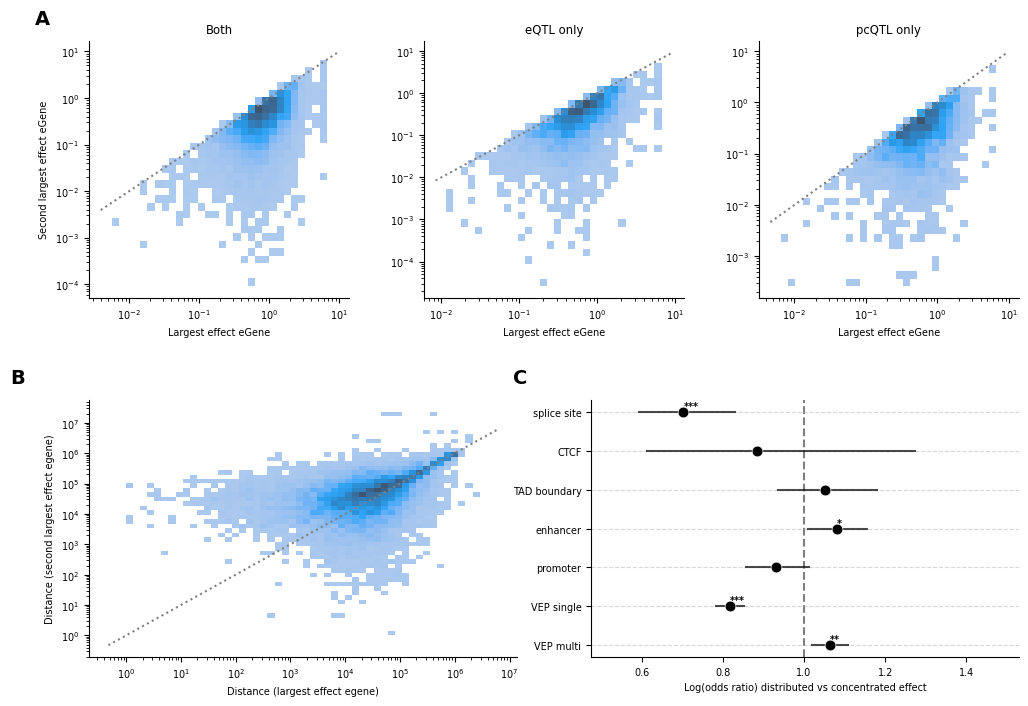

In [150]:
# Create the combined figure with 5 subplots
fig = plt.figure(figsize=(12, 8))

# Create a 6-column grid spec for equal width bottom plots
gs = fig.add_gridspec(2, 6, height_ratios=[1, 1], width_ratios=[1, 1, 1, 1, 1, 1], hspace=0.4, wspace=0.8)

# Top row - three panels (each spanning 2 columns)
# Panel A: Both
ax1 = fig.add_subplot(gs[0, 0:2])
data_both = cluster_grouped_afc.groupby('signal_id').first()
data_both = data_both[data_both['qtl_group_label'] == 'Both']
sns.histplot(data_both, x='max_abs_pip_afc_weighted', y='second_abs_pip_afc_weighted', 
             bins=30, log_scale=(True, True), ax=ax1, stat='density')
ax1.plot(ax1.get_xlim(), ax1.get_xlim(), color='grey', ls=':')
ax1.set_xlabel('Largest effect eGene')
ax1.set_ylabel('Second largest effect eGene')
ax1.set_title('Both')
ax1.spines[['top', 'right']].set_visible(False)
ax1.text(-0.15, 1.05, 'A', transform=ax1.transAxes, fontsize=14, fontweight='bold', 
           ha='right', va='bottom')

# Panel B: eQTL only
ax2 = fig.add_subplot(gs[0, 2:4])
data_eqtl = cluster_grouped_afc.groupby('signal_id').first()
data_eqtl = data_eqtl[data_eqtl['qtl_group_label'] == 'eQTL only']
sns.histplot(data_eqtl, x='max_abs_pip_afc_weighted', y='second_abs_pip_afc_weighted', 
             bins=30, log_scale=(True, True), ax=ax2, stat='density')
ax2.plot(ax2.get_xlim(), ax2.get_xlim(), color='grey', ls=':')
ax2.set_xlabel('Largest effect eGene')
ax2.set_ylabel('')
ax2.set_title('eQTL only')
ax2.spines[['top', 'right']].set_visible(False)


# Panel C: pcQTL only
ax3 = fig.add_subplot(gs[0, 4:6])
data_pcqtl = cluster_grouped_afc.groupby('signal_id').first()
data_pcqtl = data_pcqtl[data_pcqtl['qtl_group_label'] == 'pcQTL only']
sns.histplot(data_pcqtl, x='max_abs_pip_afc_weighted', y='second_abs_pip_afc_weighted', 
             bins=30, log_scale=(True, True), ax=ax3, stat='density')
ax3.plot(ax3.get_xlim(), ax3.get_xlim(), color='grey', ls=':')
ax3.set_xlabel('Largest effect eGene')
ax3.set_ylabel('')
ax3.set_title('pcQTL only')
ax3.spines[['top', 'right']].set_visible(False)

# Bottom row - Distance plot and Annotation enrichment (each spanning 3 columns = 1/2 width)
# Panel D: Distance plot
ax4 = fig.add_subplot(gs[1, 0:3])
sns.histplot(cluster_grouped_afc.groupby('signal_id').first(), 
             x='distance_first', y='distance_second', 
             bins=50, ax=ax4, log_scale=True)
ax4.plot(ax4.get_xlim(), ax4.get_xlim(), color='grey', ls=':')
ax4.spines[['top', 'right']].set_visible(False)
ax4.set_xlabel('Distance (largest effect egene)')
ax4.set_ylabel('Distance (second largest effect egene)')
ax4.text(-0.15, 1.05, 'B', transform=ax4.transAxes, fontsize=14, fontweight='bold', 
           ha='right', va='bottom')

# Panel E: Annotation enrichment
ax5 = fig.add_subplot(gs[1, 3:6])
# Create the annotation enrichment plot
enrichment_data = enrichment[enrichment['reason'] == 'success'].copy()
enrichment_data = enrichment_data[enrichment_data['annotation'] != 'nmd']  # Remove nmd due to complete separation

# Create bar plot for annotation enrichment

# Panel: Enrichment of genomic annotations (single category)

# Define y-positions for each annotation
y_positions = {annotation: i for i, annotation in enumerate(column_list)}
for i, (idx, row) in enumerate(enrichment.iterrows()):
    y_val = y_positions[row['annotation']]
    ax5.scatter(row['odds_ratio'], y_val, 
               color='black', s=60,
               zorder=3, edgecolors='white', linewidth=0.5)
    log_lower_ci = row['ci_lower']
    log_upper_ci = row['ci_upper']

    ax5.plot([log_lower_ci, log_upper_ci], [y_val, y_val], 
            color='black', alpha=0.7, linewidth=1.5, zorder=2)
    if pd.notna(row['p_value']):
        if row['p_value'] < 0.001:
            marker = '***'
        elif row['p_value'] < 0.01:
            marker = '**'
        elif row['p_value'] < 0.05:
            marker = '*'
        else:
            marker = ''
        
        if marker:
            ax5.text(row['odds_ratio'] , y_val + 0.15, marker, 
                   va='center', color='black', fontweight='bold', zorder=4)
ax5.axvline(x=1, color='black', linestyle='--', alpha=0.5, zorder=1)
column_labels = ['', 'VEP multi', 
    'VEP single', 
    'promoter', 
    'enhancer', 
    'TAD boundary', 
    'CTCF', 
    'splice site']
ax5.set_yticklabels(column_labels)

# Customize the plot
ax5.set_xlabel('Log odds ratio')
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
ax5.grid(axis='y', linestyle='--', alpha=0.5)

# Set reasonable x-axis limits
if len(enrichment) > 0:
    log_lower_ci_all = enrichment['ci_lower'].min()
    log_upper_ci_all = enrichment['ci_upper'].max()
    x_margin = 0.2
    ax5.set_xlim(log_lower_ci_all * (1 - x_margin), log_upper_ci_all * (1 + x_margin))

ax5.set_xlabel('Log(odds ratio) distributed vs concentrated effect')
ax5.text(-0.15, 1.05, 'C', transform=ax5.transAxes, fontsize=14, fontweight='bold', 
           ha='right', va='bottom')

# Save the complete figure
plt.savefig("/home/klawren/oak/pcqtls/workflow/supplemental_figures/figures/figure_s9.pdf", 
            transparent=True, dpi=300, bbox_inches='tight')

plt.show()